In [1]:
import zipfile
import os

zip_file_path = '/content/archive (1).zip'
extract_dir = '/content/unzipped_data'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files unzipped to: {extract_dir}")

# List the contents of the unzipped directory
print("Contents of unzipped directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Files unzipped to: /content/unzipped_data
Contents of unzipped directory:
/content/unzipped_data/Employee.csv


In [6]:
import pandas as pd

employee_df = pd.read_csv('/content/unzipped_data/Employee.csv')
display(employee_df)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [8]:
from google.colab import sheets, auth

# Explicitly authenticate the user to ensure credential propagation
auth.authenticate_user()

sheet = sheets.InteractiveSheet(df=employee_df)

https://docs.google.com/spreadsheets/d/1nEzEPK835zo8TaDm32KBEK2SXTcFkC2XvZdhMFUEZ5Y/edit#gid=0


/tmp/ipykernel_13127/3387576268.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Education', y='Count', data=education_counts, palette='viridis')


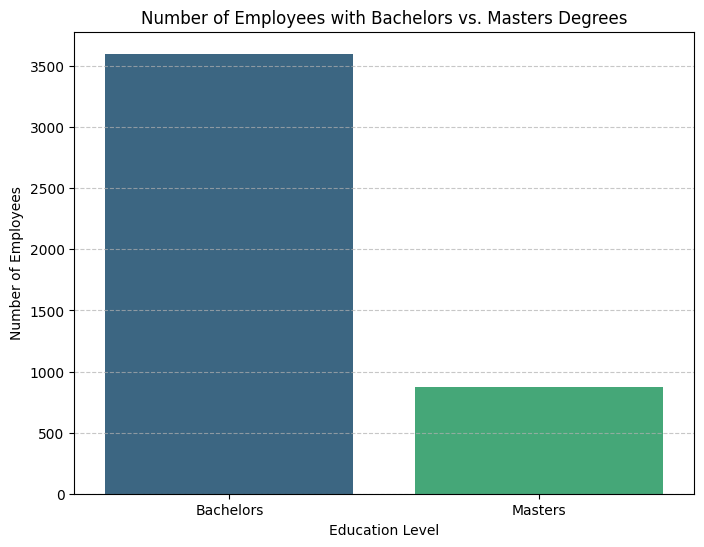

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for only 'Bachelors' and 'Masters' in Education
education_counts = employee_df[employee_df['Education'].isin(['Bachelors', 'Masters'])]['Education'].value_counts().reset_index()
education_counts.columns = ['Education', 'Count']

plt.figure(figsize=(8, 6))
sns.barplot(x='Education', y='Count', data=education_counts, palette='viridis', hue='Education', legend=False)
plt.title('Number of Employees with Bachelors vs. Masters Degrees')
plt.xlabel('Education Level')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

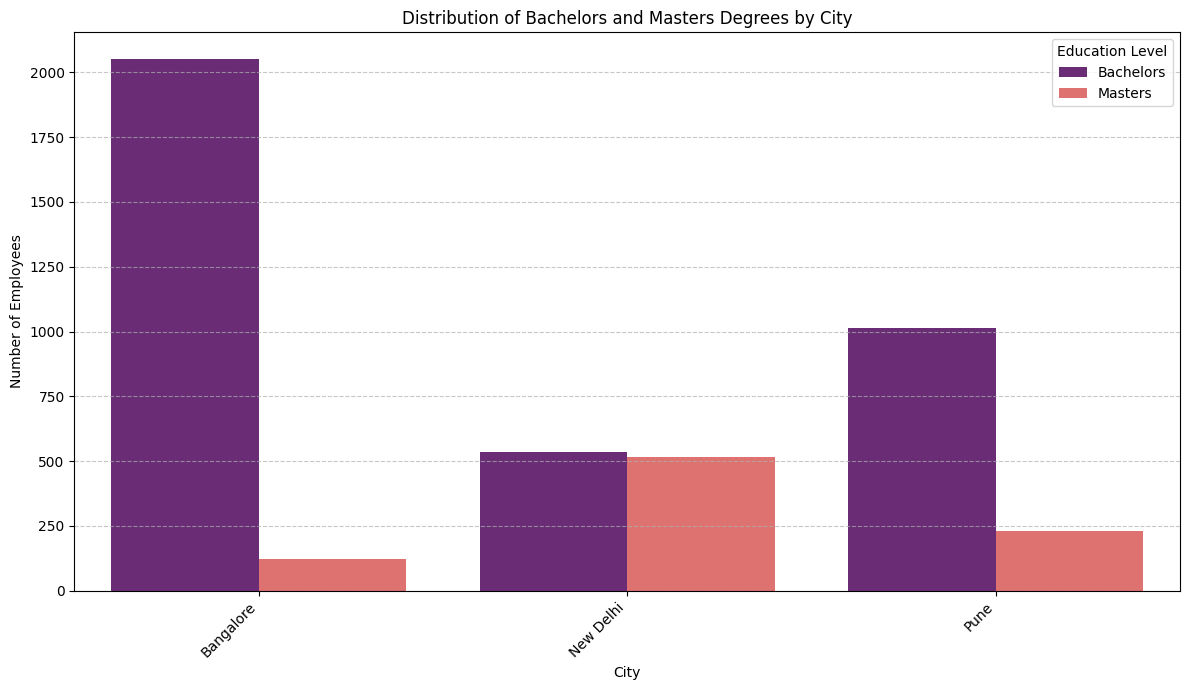

In [10]:
# Now, let's visualize the distribution by city
# Filter for only 'Bachelors' and 'Masters' and get counts by City and Education
city_education_counts = employee_df[employee_df['Education'].isin(['Bachelors', 'Masters'])].groupby(['City', 'Education']).size().reset_index(name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(x='City', y='Count', hue='Education', data=city_education_counts, palette='magma')
plt.title('Distribution of Bachelors and Masters Degrees by City')
plt.xlabel('City')
plt.ylabel('Number of Employees')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Education Level')
plt.tight_layout()
plt.show()

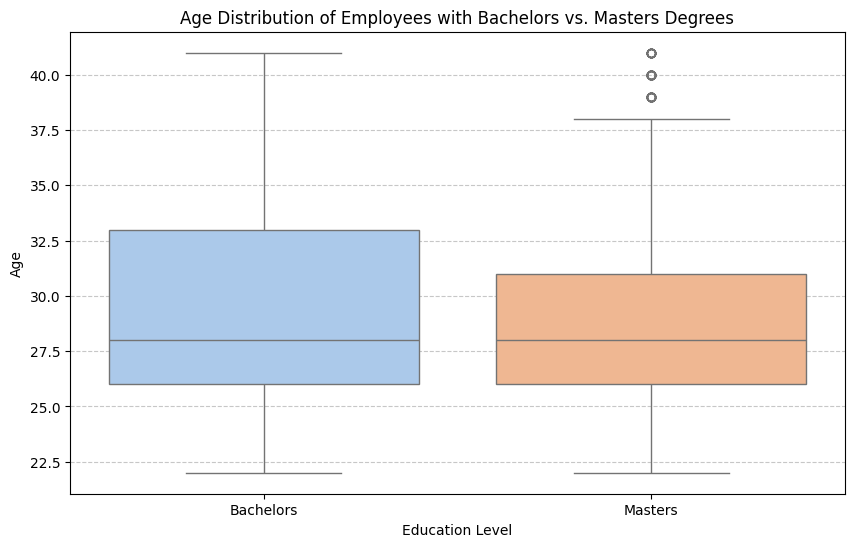

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Education', y='Age', data=employee_df[employee_df['Education'].isin(['Bachelors', 'Masters'])], palette='pastel', hue='Education', legend=False)
plt.title('Age Distribution of Employees with Bachelors vs. Masters Degrees')
plt.xlabel('Education Level')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()